Objective

The objective of feature selection is to identify the most relevant input variables that significantly influence crop yield prediction. Selecting the right features improves model performance, reduces overfitting, and decreases computational complexity.


Import Libraries

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

from sklearn.ensemble import RandomForestRegressor


Load Dataset

In [46]:
df = pd.read_csv("../data/crop_yield_feature_engineered.csv")

df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature,Fertilizer_per_Area,Pesticide_per_Area,Rainfall_per_Area,Temperature_Range,Climate_Index
0,0,1997,4,2,11.209317,10.945688,2051.4,15.764969,10.038164,0.7960,23.692,33.435,14.779,1.291224,0.822172,168.019223,18.656,1037.546
1,1,1997,1,2,8.800566,8.452335,2051.4,13.356082,7.629718,0.7100,23.692,33.435,14.779,1.362787,0.778498,209.314442,18.656,1037.546
2,8,1997,1,2,6.680855,3.135494,2051.4,11.235277,5.512461,0.2380,23.692,33.435,14.779,1.462764,0.717688,267.079653,18.656,1037.546
3,9,1997,4,2,9.886189,18.434232,2051.4,14.441803,8.715119,5.0725,23.692,33.435,14.779,1.326617,0.800567,188.440605,18.656,1037.546
4,11,1997,1,2,7.461640,6.678342,2051.4,12.016736,6.291736,0.4210,23.692,33.435,14.779,1.420143,0.743560,242.435261,18.656,1037.546


Check Dataset

In [47]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop                 19689 non-null  int64  
 1   Crop_Year            19689 non-null  int64  
 2   Season               19689 non-null  int64  
 3   State                19689 non-null  int64  
 4   Area                 19689 non-null  float64
 5   Production           19689 non-null  float64
 6   Annual_Rainfall      19689 non-null  float64
 7   Fertilizer           19689 non-null  float64
 8   Pesticide            19689 non-null  float64
 9   Yield                19689 non-null  float64
 10  Avg_Temperature      19689 non-null  float64
 11  Max_Temperature      19689 non-null  float64
 12  Min_Temperature      19689 non-null  float64
 13  Fertilizer_per_Area  19689 non-null  float64
 14  Pesticide_per_Area   19689 non-null  float64
 15  Rainfall_per_Area    19689 non-null  float64
 1

(19689, 18)

Separate Features and Target

In [48]:
X = df.drop("Yield", axis=1)

y = df["Yield"]

Feature Correlation

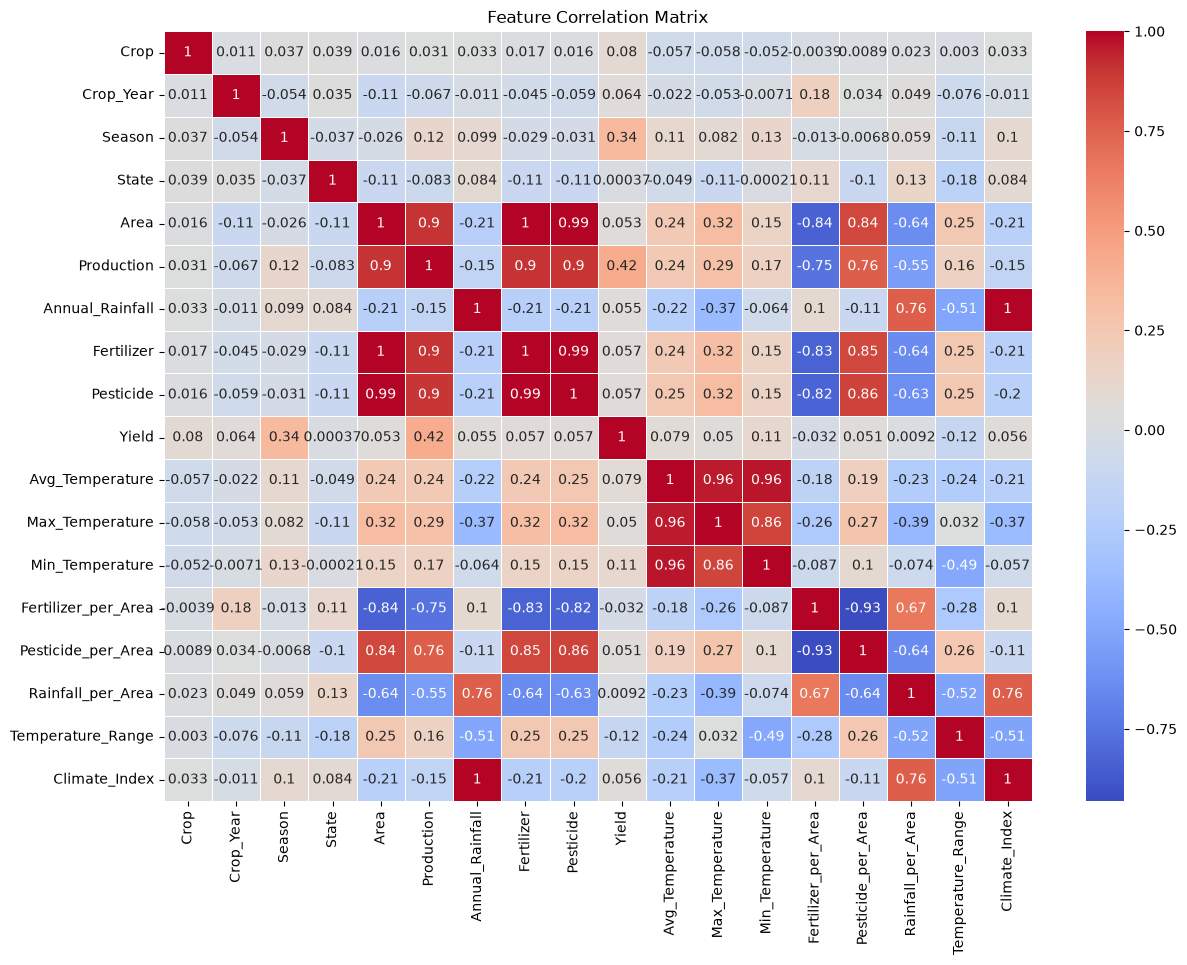

In [49]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidth=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

Correlation with Target

In [50]:
target_corr = correlation["Yield"].sort_values(ascending=False)

print(target_corr)



Yield                  1.000000
Production             0.424769
Season                 0.340221
Min_Temperature        0.105076
Crop                   0.080172
Avg_Temperature        0.078908
Crop_Year              0.063974
Fertilizer             0.056965
Pesticide              0.056951
Climate_Index          0.055724
Annual_Rainfall        0.055074
Area                   0.053116
Pesticide_per_Area     0.051186
Max_Temperature        0.049774
Rainfall_per_Area      0.009216
State                  0.000368
Fertilizer_per_Area   -0.032372
Temperature_Range     -0.119170
Name: Yield, dtype: float64


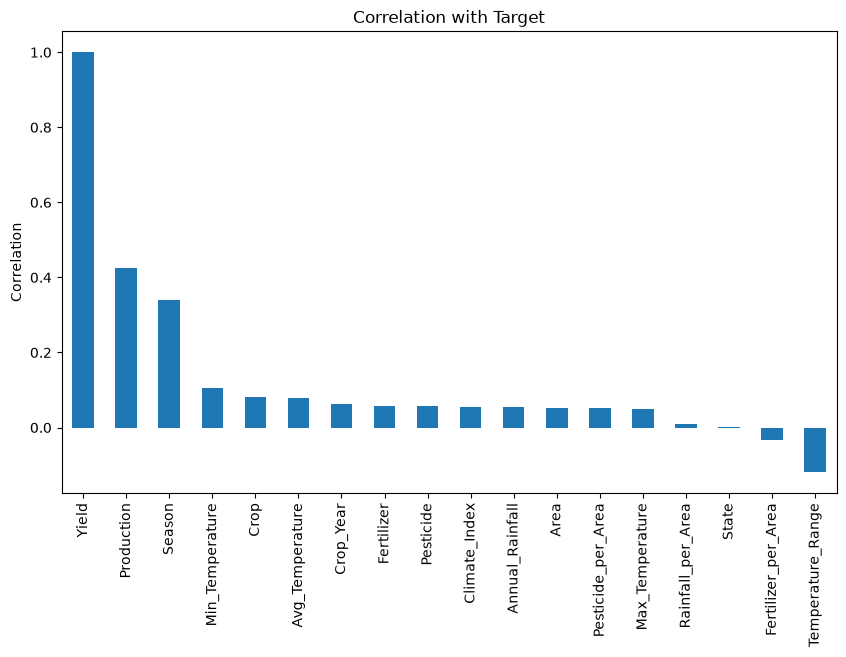

In [51]:
#Visualization
plt.figure(figsize=(10,6))

target_corr.plot(kind="bar")

plt.title("Correlation with Target")

plt.ylabel("Correlation")

plt.show()

Select K Best Feature Selection

In [52]:
selector = SelectKBest(
    score_func=f_regression,
    k='all'
)

selector.fit(X, y)

SelectKBest(k='all', score_func=<function f_regression at 0x00000188290253A0>)

Feature Scores

In [53]:
feature_scores = pd.DataFrame({

    "Feature": X.columns,

    "Score": selector.scores_

})

feature_scores.sort_values(
    by="Score",
    ascending=False,
    inplace=True
)

feature_scores

,Feature,Score
5,Production,4334.100385
2,Season,2577.067574
15,Temperature_Range,283.613813
11,Min_Temperature,219.791727
0,Crop,127.357998
9,Avg_Temperature,123.347417
1,Crop_Year,80.902683
7,Fertilizer,64.092401
8,Pesticide,64.060478
16,Climate_Index,61.320949


Plot Feature Scores

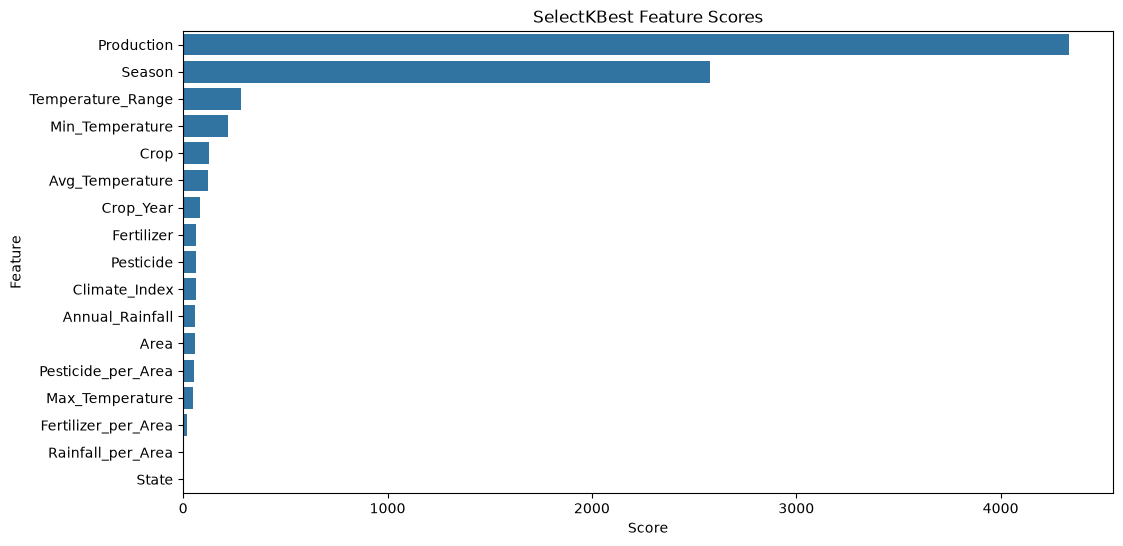

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_scores,
    x="Score",
    y="Feature"
)

plt.title("SelectKBest Feature Scores")

plt.show()


Select Top Features

In [55]:
top_features = feature_scores.head(10)

top_features


,Feature,Score
5,Production,4334.100385
2,Season,2577.067574
15,Temperature_Range,283.613813
11,Min_Temperature,219.791727
0,Crop,127.357998
9,Avg_Temperature,123.347417
1,Crop_Year,80.902683
7,Fertilizer,64.092401
8,Pesticide,64.060478
16,Climate_Index,61.320949


Random Forest Feature Importance

In [56]:

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Extract Feature Importance

In [57]:

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True)

importance

,Feature,Importance
5,Production,0.444326
4,Area,0.302522
2,Season,0.141353
7,Fertilizer,0.040605
12,Fertilizer_per_Area,0.024615
11,Min_Temperature,0.009151
8,Pesticide,0.007816
15,Temperature_Range,0.007666
0,Crop,0.005685
3,State,0.003524


Plot Feature Importance

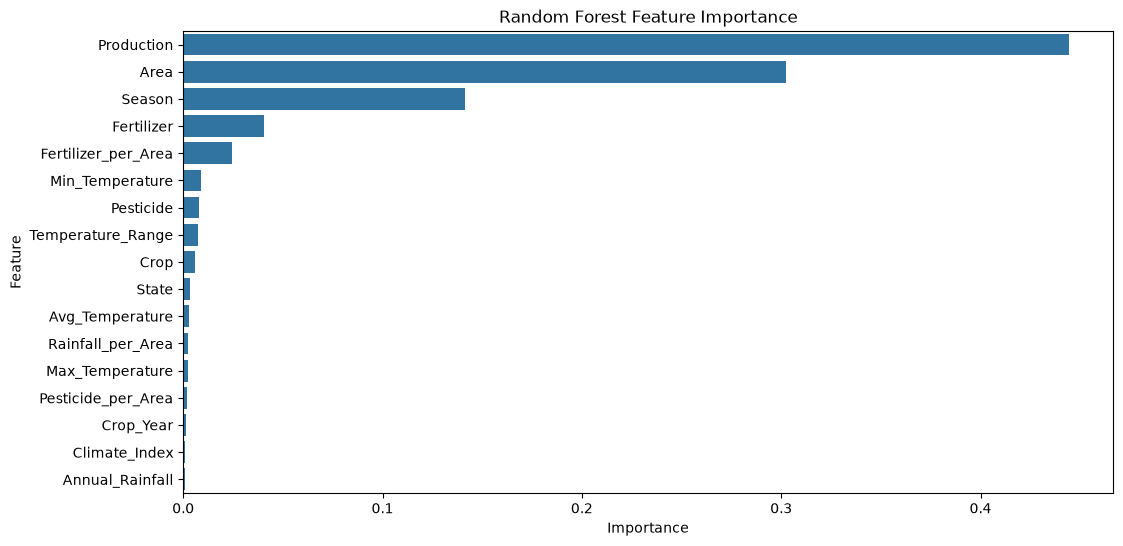

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()


Compare Both Methods

In [59]:
comparison = feature_scores.merge(
    importance,
    on="Feature"
)

comparison


,Feature,Score,Importance
0,Production,4334.100385,0.444326
1,Season,2577.067574,0.141353
2,Temperature_Range,283.613813,0.007666
3,Min_Temperature,219.791727,0.009151
4,Crop,127.357998,0.005685
5,Avg_Temperature,123.347417,0.002835
6,Crop_Year,80.902683,0.001498
7,Fertilizer,64.092401,0.040605
8,Pesticide,64.060478,0.007816
9,Climate_Index,61.320949,0.000906


Select Final Features

In [60]:
selected_features = importance[
    importance["Importance"] > 0.01
]["Feature"]

selected_features

5              Production
4                    Area
2                  Season
7              Fertilizer
12    Fertilizer_per_Area
Name: Feature, dtype: str

Create Final Dataset

In [61]:

X_selected = X[selected_features]

X_selected.head()



,Production,Area,Season,Fertilizer,Fertilizer_per_Area
0,10.945688,11.209317,4,15.764969,1.291224
1,8.452335,8.800566,1,13.356082,1.362787
2,3.135494,6.680855,1,11.235277,1.462764
3,18.434232,9.886189,4,14.441803,1.326617
4,6.678342,7.461640,1,12.016736,1.420143


Check Shape

In [62]:

print("Original Shape :", X.shape)

print("Selected Shape :", X_selected.shape)


Original Shape : (19689, 17)
Selected Shape : (19689, 5)


Save Selected Dataset

In [63]:

final_df = pd.concat(
    [X_selected, y],
    axis=1
)

In [64]:
from pathlib import Path

# Current notebook location
print(Path.cwd())

# If notebook is in notebooks/
project_root = Path.cwd().parent

data_folder = project_root / "data"
data_folder.mkdir(exist_ok=True)  # Creates the folder if it doesn't exist

final_df.to_csv(
    data_folder / "crop_yield_selected_features.csv",
    index=False
)

c:\Users\Ranjana\Crop_Yield_Prediction\notebooks


Summary

In [65]:
print("Original Features :", X.shape[1])

print("Selected Features :", X_selected.shape[1])

Original Features : 17
Selected Features : 5
